# Bank Marketing
- By: ABeer Al-Zebda | Machine Learning Engineer

# Abstract:
The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).

# Data Set Information:
The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed.

Data Link : https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing

# Data Dictionary

- Age (numeric)
- Job : type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services','student', 'technician', 'unemployed', 'unknown')
- Marital : marital status (categorical: 'divorced', 'married', 'single', 'unknown' ; note: 'divorced' means divorced or widowed)
- Education (categorical: 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown')
- Default: has credit in default? (categorical: 'no', 'yes', 'unknown')
- Housing: has housing loan? (categorical: 'no', 'yes', 'unknown')
- Loan: has personal loan? (categorical: 'no', 'yes', 'unknown')
- Contact: contact communication type (categorical:'cellular','telephone')
- Month: last contact month of year (categorical: 'jan', 'feb', 'mar',…, 'nov', 'dec')
- Day_of_week: last contact day of the week (categorical:'mon','tue','wed','thu','fri')
- Duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., ifduration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known.
Thus, this input should only be included for benchmark purposes and
should be discarded if the intention is to have a realistic
predictive model.
- Campaign: number of contacts performed during this campaign and for
this client (numeric, includes last contact)
- Pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
- Previous: number of contacts performed before this campaign and for
this client (numeric)
- Poutcome: outcome of the previous marketing campaign (categorical:
'failure','nonexistent','success')
- Emp.var.rate: employment variation rate - quarterly indicator
(numeric)
- Cons.price.idx: consumer price index - monthly indicator (numeric)
- Cons.conf.idx: consumer confidence index - monthly indicator
(numeric)
- Euribor3m: euribor 3 month rate - daily indicator (numeric)
- Nr.employed: number of employees - quarterly indicator (numeric)
- y - has the client subscribed a term deposit? (binary: 'yes', 'no')
  

# Import libraries

In [58]:

# Pandas is used to read and handle the dataset
import pandas as pd

# Matplotlib is used for plotting
import matplotlib.pyplot as plt
import seaborn as sns
# train_test_split is used to divide the data into training and testing sets
from sklearn.model_selection import train_test_split

# StandardScaler is used to standardize the features
from sklearn.preprocessing import StandardScaler, OneHotEncoder 

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline

# LogisticRegression is the ready-made classification model in scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor 
# Accuracy score, confusion matrix, and classification report are used for evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load the dataset

In [76]:

# Read CSV with semicolon delimiter
df = pd.read_csv('bank-additional-full.csv', delimiter=';')

# Show the first 5 rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Inspect the data

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [10]:
for col in df:
    print(df[col].value_counts())

age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
91       2
98       2
95       1
87       1
94       1
Name: count, Length: 78, dtype: int64
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
housing
yes        21576
no         18622
unknown      990
Name: count, 

In [11]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


# Clean The Data

In [20]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(12)

In [24]:
df =df.drop_duplicates() 
df.duplicated().sum()

np.int64(0)

# Explore the Data

<Axes: xlabel='y', ylabel='age'>

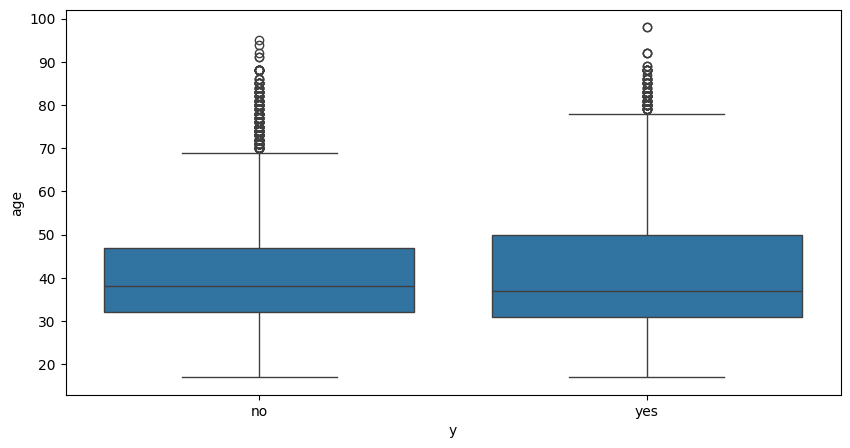

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x= 'y' , y='age')

<Axes: xlabel='campaign', ylabel='duration'>

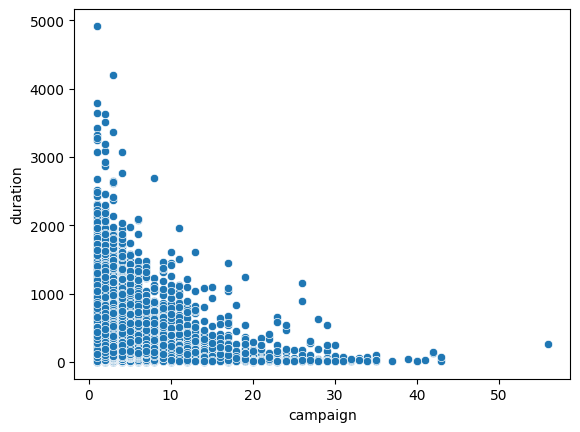

In [28]:
sns.scatterplot(data=df , y='duration' , x='campaign')

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df ,x ='job' )
ax.set_xticklabels(ax.get_xticklabels() ,rotation=90);

# Prepare input features and target 

In [77]:
# Create the input feature matrix
X = df.drop("y", axis=1)

# Create the target vector
y = df ["y"]


# Split the data using scikit-learn

In [78]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Preprocessing 

In [42]:
# Create the preprocessing pipeline for categorical data
cat_selector =  X_train.select_dtypes('object').columns
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_pipe = make_pipeline(ohe)

cat_tuple = ('categorical',cat_pipe, cat_selector)
cat_tuple

('categorical',
 Pipeline(steps=[('onehotencoder',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'day_of_week', 'poutcome'],
       dtype='object'))

In [43]:
# define numeric features and object features
num_cols = X_train.select_dtypes("number").columns

# feature scaling 
scaler = StandardScaler()  

# Instantiate the pipeline
num_pipe = make_pipeline(scaler)

# Make the tuple for ColumnTransformer
num_tuple = ('numeric',num_pipe,num_cols)
num_tuple

('numeric',
 Pipeline(steps=[('standardscaler', StandardScaler())]),
 Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
        'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
       dtype='object'))

In [44]:
# Create the preprocessing ColumnTransformer
preprocessor = ColumnTransformer([cat_tuple, num_tuple],
verbose_feature_names_out=False)

preprocessor

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')),
                                ('numeric',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler())]),
                                 Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object'))],
                  verbose_feature_names_out=False)

In [45]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')),
                                ('numeric',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler())]),
                                 Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object'))],
                  verbose_feature_names_out=False)

In [46]:
x_train_transformed=preprocessor.transform(X_train)
x_test_transformed=preprocessor.transform(X_test)

# Building (LogisticRegression ) Model

In [47]:
# Create the logistic regression model
model = LogisticRegression(max_iter=1000)

# Train the model on the scaled training data
model.fit(x_train_transformed, y_train)

LogisticRegression(max_iter=1000)

# Evaluate Model

In [48]:
y_train_pred = model.predict(x_train_transformed)
y_test_pred  = model.predict(x_test_transformed)

print("Training accuracy:", round(accuracy_score(y_train, y_train_pred), 4))
print("Testing accuracy :", round(accuracy_score(y_test, y_test_pred), 4))

Training accuracy: 0.9119
Testing accuracy : 0.9113


In [49]:
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

              precision    recall  f1-score   support

          no       0.93      0.97      0.95      7303
         yes       0.67      0.43      0.52       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238

[[7104  199]
 [ 532  403]]


In [50]:
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print("          Pred 0   Pred 1")
print("Actual 0   ", cm[0,0], "   ", cm[0,1])
print("Actual 1   ", cm[1,0], "   ", cm[1,1])

Confusion Matrix:
          Pred 0   Pred 1
Actual 0    7104     199
Actual 1    532     403


# Interpret the results

Class 1 — "yes" (client subscribed)

- Precision 0.67 → When the model predicts "yes", it's correct 67% of the time (33% are False Positives — predicted "yes" but actually "no")
- Recall 0.43 → The model correctly catches 43% of all actual "yes" clients, missing 57% → those missed are False Negatives (predicted "no" but actually "yes")

Class 0 — "no" (client did NOT subscribe)

- Precision 0.93 → When the model predicts "no", it's correct 93% of the time (7% are False Positives — predicted "no" but actually "yes")
- Recall 0.97 → The model correctly catches 97% of all actual "no" clients, missing only 3% → those missed are False Negatives (predicted "yes" but actually "no")

# Predict on new Data

In [53]:
# Step 1: Create new client samples
new_data = pd.DataFrame({
    'age':            [35,        52,        28       ],
    'job':            ['admin.',  'technician', 'student'],
    'marital':        ['married', 'single',  'single' ],
    'education':      ['university.degree', 'high.school', 'basic.9y'],
    'default':        ['no',      'no',      'no'     ],
    'housing':        ['yes',     'no',      'yes'    ],
    'loan':           ['no',      'yes',     'no'     ],
    'contact':        ['cellular','telephone','cellular'],
    'month':          ['may',     'jun',     'aug'    ],
    'day_of_week':    ['mon',     'wed',     'fri'    ],
    'duration':       [200,       350,       180      ],
    'campaign':       [2,         1,         3        ],
    'pdays':          [999,       5,         999      ],   # 999 = client not previously contacted
    'previous':       [0,         1,         0        ],
    'poutcome':       ['nonexistent', 'success', 'nonexistent'],
    'emp.var.rate':   [-1.8,      1.1,       -2.9     ],
    'cons.price.idx': [92.893,    93.994,    92.201   ],
    'cons.conf.idx':  [-46.2,     -36.4,     -31.4    ],
    'euribor3m':      [1.313,     4.857,     0.869    ],
    'nr.employed':    [5099.1,    5191.0,    5076.2   ]
})

print("New Client Samples:")
print(new_data)
print()



New Client Samples:
   age         job  marital          education  ... cons.price.idx cons.conf.idx euribor3m nr.employed
0   35      admin.  married  university.degree  ...         92.893         -46.2     1.313      5099.1
1   52  technician   single        high.school  ...         93.994         -36.4     4.857      5191.0
2   28     student   single           basic.9y  ...         92.201         -31.4     0.869      5076.2

[3 rows x 20 columns]



In [ ]:

# Step 2: Transform using your preprocessor (encodes strings to numbers)
new_x = preprocessor.transform(new_data)
# Step 3: Predict using your model
y_pred = model.predict(new_x)

# Step 4: Display results
results = pd.DataFrame({
    'Age':          new_data['age'].values,
    'Job':          new_data['job'].values,
    'Marital':      new_data['marital'].values,
    'Education':    new_data['education'].values,
    'Housing Loan': new_data['housing'].values,
    'Month':        new_data['month'].values,
    'Prediction':   ['Will Subscribe ✅' if p == 'yes' else 'Will NOT Subscribe ❌' for p in y_pred]
})

print("Predicted Client Subscription:")
print(results)

In [57]:
sample = new_x[0].reshape(1, -1)

print("Probability:", round(model.predict_proba(sample)[0, 1], 4))
print("Predicted  :", model.predict(sample)[0])
print("Actual     :", y_test.iloc[0])

Probability: 0.0503
Predicted  : no
Actual     : no


# Building ( RandomForestRegressor ) Model

In [82]:
y_train_encoded = y_train.map({'no': 0, 'yes': 1})
y_test_encoded  = y_test.map({'no': 0, 'yes': 1})

# Create the RandomForestRegressor model
model = RandomForestRegressor(random_state=42)

# Train the model on the scaled training data
model.fit(x_train_transformed, y_train_encoded)


RandomForestRegressor(random_state=42)

In [84]:

y_train_pred = model.predict(x_train_transformed)
y_test_pred  = model.predict(x_test_transformed)

threshold = 0.5
y_train_pred_binary = (y_train_pred >= threshold).astype(int)
y_test_pred_binary  = (y_test_pred  >= threshold).astype(int)

from sklearn.metrics import accuracy_score
print("Training accuracy:", round(accuracy_score(y_train_encoded, y_train_pred_binary), 4))
print("Testing accuracy :", round(accuracy_score(y_test_encoded, y_test_pred_binary), 4))

Training accuracy: 1.0
Testing accuracy : 0.9137


In [92]:
y_test_pred_labels = np.where(y_test_pred >= threshold, 'yes', 'no')

print(classification_report(y_test, y_test_pred_labels))
print(confusion_matrix(y_test, y_test_pred_labels))

              precision    recall  f1-score   support

          no       0.95      0.96      0.95      7303
         yes       0.63      0.58      0.60       935

    accuracy                           0.91      8238
   macro avg       0.79      0.77      0.78      8238
weighted avg       0.91      0.91      0.91      8238

[[6985  318]
 [ 393  542]]
